<a href="https://colab.research.google.com/github/Saiful-2/house-price-prediction/blob/main/notebooks/9_housing_shap_explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🔹 1. Install & Import

In [1]:
# If needed
!pip install shap

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import GradientBoostingRegressor

## 🔹 2. Load Dataset

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/Saiful-2/datasets/main/ames_housing_cleaned.csv")

df.head()

,ms_subclass,ms_zoning,lot_frontage,lot_area,street,alley,lot_shape,land_contour,utilities,lot_config,...,pool_area,pool_qc,fence,misc_feature,misc_val,mo_sold,yr_sold,sale_type,sale_condition,saleprice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,Ex,NaN,Shed,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,Ex,MnPrv,Shed,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,Ex,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,Ex,NaN,Shed,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,Ex,MnPrv,Shed,0,3,2010,WD,Normal,189900


## 🔹 3. Define Features & Target

In [5]:
target = "log_saleprice"
df[target] = np.log(df['saleprice'])

X = df.drop(columns=[target])
y = df[target]

## 🔹 4. Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 🔹 5. Preprocessing Pipeline (Same as before)

In [7]:
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer([
    ('num', 'passthrough', numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

## 🔹 6. Model Pipeline

In [8]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ))
])

## 🔹 7. Train Model

In [9]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['ms_subclass', 'lot_frontage', 'lot_area', 'overall_qual',
       'overall_cond', 'year_built', 'year_remodadd', 'mas_vnr_area',
       'bsmtfin_sf_1', 'bsmtfin_sf_2', 'bsmt_unf_sf', 'total_bsmt_sf',
       '1st_flr_sf', '2nd_flr_sf', 'low_qual_fin_sf', 'gr_liv_area',
       'bsmt_full_bath', 'bsmt_hal...
       'bsmtfin_type_1', 'bsmtfin_type_2', 'heating', 'heating_qc',
       'central_air', 'electrical', 'kitchen_qual', 'functional',
       'fireplace_qu', 'garage_type', 'garage_finish', 'garage_qual',
       'garage_cond', 'paved_drive', 'pool_qc', 'fence', 'misc_feature',
       'sale_type', 'sale_condition'],
      dtype='object'))])),
                ('regressor',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=200,
                                           random_state=42))])

## 🔹 8. Transform Data for SHAP

In [10]:
X_train_transformed = model.named_steps['preprocessor'].transform(X_train)
X_test_transformed = model.named_steps['preprocessor'].transform(X_test)

## 🔹 9. Get Feature Names

In [11]:
ohe = model.named_steps['preprocessor'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out(categorical_cols)

feature_names = np.concatenate([numerical_cols, cat_features])

## 🔹 10. Create SHAP Explainer
For tree-based models:

In [13]:
explainer = shap.Explainer(model.named_steps['regressor'])
shap_values = explainer(X_test_transformed.toarray())

## 🔹 11. SHAP Summary Plot

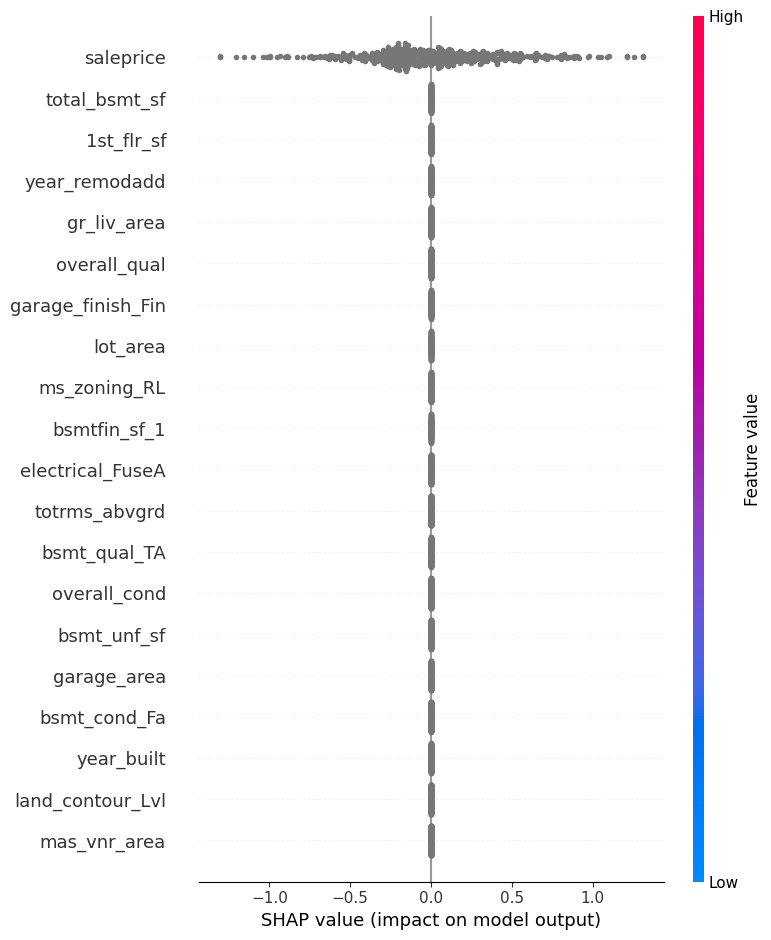

In [14]:
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

## 🔹 12. SHAP Bar Plot

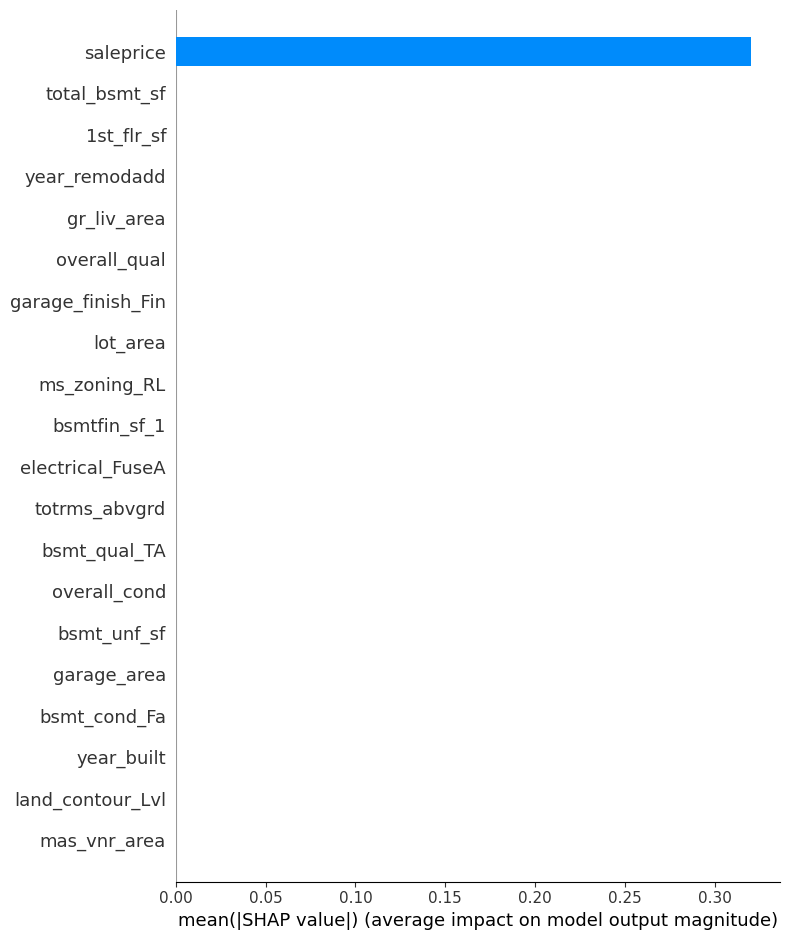

In [15]:
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type="bar")

## 🔹 13. Explain a Single Prediction

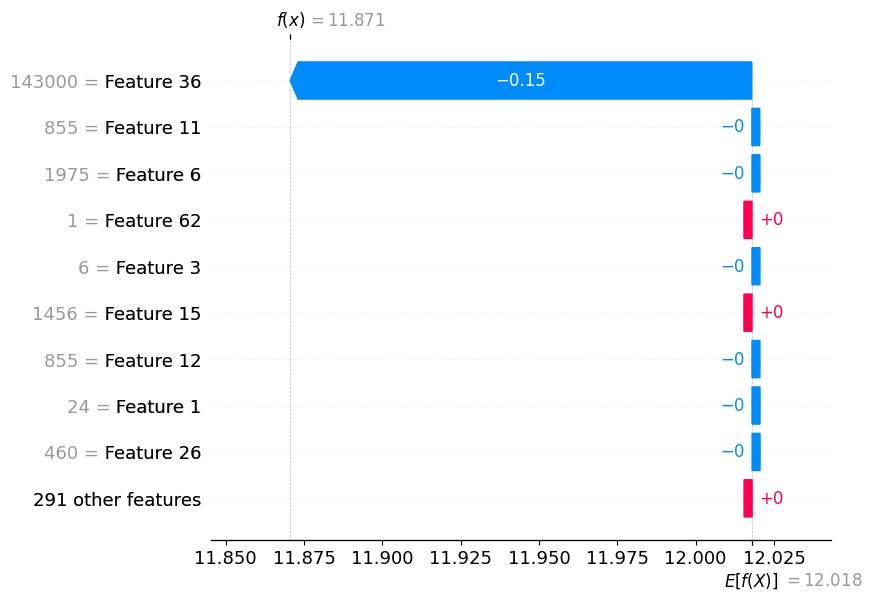

In [16]:
sample_index = 0

shap.plots.waterfall(shap_values[sample_index])

## 🔹 14. Force Plot

In [17]:
shap.initjs()

shap.plots.force(
    explainer.expected_value,
    shap_values.values[sample_index],
    feature_names=feature_names
)

## 🔹 15. Dependence Plot

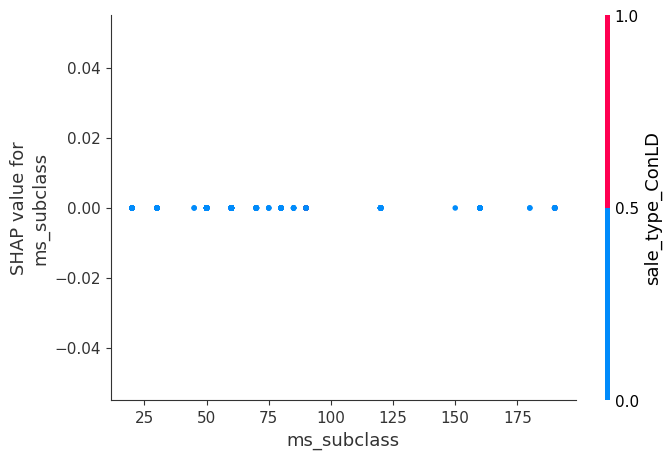

In [19]:
# Choose top feature manually after summary plot
shap.dependence_plot(
    feature_names[0],
    shap_values.values,
    X_test_transformed.toarray(),
    feature_names=feature_names
)

## 🔹 16. Aggregate SHAP Importance

In [20]:
shap_importance = np.abs(shap_values.values).mean(axis=0)

shap_df = pd.DataFrame({
    "Feature": feature_names,
    "SHAP Importance": shap_importance
}).sort_values(by="SHAP Importance", ascending=False)

shap_df.head(15)

,Feature,SHAP Importance
36,saleprice,0.320331
11,total_bsmt_sf,0.000137
12,1st_flr_sf,0.000067
6,year_remodadd,0.000034
15,gr_liv_area,0.000029
3,overall_qual,0.000025
255,garage_finish_Fin,0.000024
2,lot_area,0.000023
42,ms_zoning_RL,0.000020
8,bsmtfin_sf_1,0.000017


## 🔹 17. SHAP Importance Plot

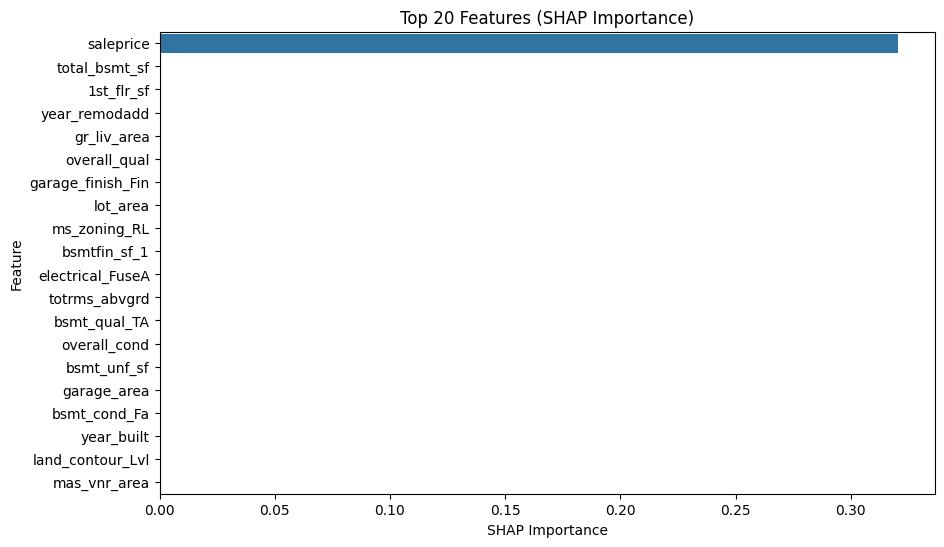

In [21]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=shap_df.head(20),
    x="SHAP Importance",
    y="Feature"
)
plt.title("Top 20 Features (SHAP Importance)")
plt.show()

## 🔹 18. Save Results

In [22]:
shap_df.to_csv("shap_feature_importance.csv", index=False)

## 19. Final Insights
## SHAP Explainability Insights

- SHAP confirms that:
  - Overall quality and living area are the strongest predictors
  - Location (Neighborhood) significantly impacts price

- SHAP provides:
  - Global interpretation (feature importance)
  - Local interpretation (individual prediction reasoning)

### Key Insight:
👉 The model decisions are **interpretable and aligned with real-world housing economics**

### Final Conclusion:
SHAP enhances model trust and transparency, making the model suitable for real-world applications.